# Implementation of the Hamiltonian simulation proposal over a randomized set of choices of hyper-parameters $(t, \gamma)$

$\renewcommand{\ket}[1]{\left|#1\right\rangle}\renewcommand{\bra}[1]{\left\langle #1\right|}\renewcommand{\braket}[2]{\left\langle #1 \middle| #2 \right\rangle}\renewcommand{\ketbra}[2]{\left|#1\right\rangle\!\left\langle #2\right|}$

This notebook shows how to ...

**Table of contents**

1. [Import](#import)
2. [Construction of the averaging transition probability matrix](#xxx)
3. [Determine a single, fixed value of $(t^*, \gamma^*)$](#xxy)

## Import 

In [13]:
import sys

if ".." not in sys.path:
    sys.path.append("..")
    
import json
import matplotlib.pyplot as plt
import numpy as np
from monaqa2.data.filename import CONVERGENCE_RANDOMIZED_HYPERPARAMS_FILE
from monaqa2.data.instances import load_instances
from monaqa2.mcmc.proposal import create_proposal_matrix_quantum_exact, create_proposal_matrix_quantum_layden
from monaqa2.mcmc.transition import create_transition_matrix
from monaqa2.mcmc.model import IsingModel

## Construction of the averaged trial proposal matrix

Let $H_{\mathrm{tf}}(\gamma)=(1-\gamma)H+\gamma H_{\mathrm{mix}}$ be the transverse-field Hamiltonian, where $H$ is the Ising Hamiltonian and $H_{\mathrm{mix}}$ is the transverse-field mixer. The trial proposal matrix for the Hamiltonian-simulation move is defined as

$$T_{yx} = \frac{1}{(t_1 - t_0)(\gamma_1 - \gamma_0)} \int_{t_0}^{t_1} \int_{\gamma_0}^{\gamma_1} \left|\bra{y} \exp(-i t H_{\mathrm{tf}}(\gamma)) \ket{x}\right|^2 \; d\gamma\; dt$$

over a chosen range of time-evolution parameters $t \in [t_0,t_1]$ and transverse-field strengths $\gamma \in [\gamma_0,\gamma_1]$.

In our software, the method `create_proposal_matrix_quantum_layden` implements numerically this randomized approach and is used as our reference implementation. It is not fully exact, since the transverse-field strength $\gamma$ is discretized into 20 equally spaced midpoint values over the interval $\gamma \in [0.25,0.60]$. The average over the time-evolution parameter $t \in [2,20]$, instead, is evaluated exactly. For each value of $\gamma$, the Hamiltonian is diagonalized as $H_{\mathrm{tf}}(\gamma)=V\Lambda V^T$, which allows the time dependence of $|\langle y|e^{-iH_{\mathrm{tf}}(\gamma)t}|x\rangle|^2$ to be integrated analytically over $t \in [2,20]$. This calculation is implemented in `create_proposal_matrix_quantum_time_avg`. The ranges of $t$ and $\gamma$ follow the choices of Layden et al., while the 20-point discretization of $\gamma$ is used in our numerical reference implementation. The reference spectral gaps are calculated from the proposal matrices generated by this method.

To obtain a proposal that can instead be implemented using a finite set of parameter values, we discretize both $t$ and $\gamma$. For a discretization level $k$, we use $N_t=2^k$ values of $t$ and $N_\gamma=\min(2^k,20)$ values of $\gamma$, for a total of $M=N_tN_\gamma$ parameter pairs. The approximated trial proposal matrix is then

$$T_{yx} \approx \hat T_{yx}^{M} = \frac{1}{M}\sum_{j=0}^{N_t-1}\sum_{l=0}^{N_\gamma-1}\left|\bra{y}\exp(-i t_j H_{\mathrm{tf}}(\gamma_l))\ket{x}\right|^2$$

where $t_j$ and $\gamma_l$ are equally spaced midpoint values in $[2,20]$ and $[0.25,0.60]$, respectively. Increasing $k$ refines both discretizations until $N_\gamma=20$, after which only the time discretization is further refined.

The following code calculates the spectral gaps of both the trial proposal matrix $T$ and the corresponding Metropolis transition matrix $P$ for the reference and discretized approaches. Existing results (in the data folder) are NOT recomputed. 

In [14]:
def get_spectral_gap(Q_: np.ndarray) -> float:
    evals = np.linalg.eigvalsh(np.sqrt(np.maximum(Q_ * Q_.T, 0.0)))
    return float(1.0 - np.max(np.abs(evals[:-1])))


NS = range(3, 8)
IDXS = range(100)
KS = range(1, 6)

BETA = 4.0
TIME_LIMS = (2.0, 20.0)
GAMMA_LIMS = (0.25, 0.60)

APPROACHES = ["T_exact"] + [f"T_grid_k{k}" for k in KS] + ["P_exact"] + [f"P_grid_k{k}" for k in KS]

# Each approach contains a [n][instance] table of spectral gaps.
if CONVERGENCE_RANDOMIZED_HYPERPARAMS_FILE.exists():
    with open(CONVERGENCE_RANDOMIZED_HYPERPARAMS_FILE) as f:
        spectral_gaps = json.load(f)
else:
    spectral_gaps = {}

for approach in APPROACHES:
    spectral_gaps.setdefault(approach, [[None] * len(IDXS) for _ in NS])


# Exact randomized proposal: continuous time average and 20 gamma points.
for n in NS:
    print(f"\nn={n}: ", end="")
    for idx in IDXS:
        i = n - NS.start

        if spectral_gaps["T_exact"][i][idx] is not None and spectral_gaps["P_exact"][i][idx] is not None:
            continue

        print(f".", end="")

        ising: IsingModel = load_instances(n, idx)
        T = create_proposal_matrix_quantum_layden(ising.h_rescaled, ising.J_rescaled, gamma_lims=GAMMA_LIMS, gamma_steps=20, time_lims=TIME_LIMS)

        spectral_gaps["T_exact"][i][idx] = get_spectral_gap(T)
        spectral_gaps["P_exact"][i][idx] = get_spectral_gap(create_transition_matrix(T, ising, BETA))

        # Save after every instance so interrupted calculations can resume.
        with open(CONVERGENCE_RANDOMIZED_HYPERPARAMS_FILE, "w") as f:
            json.dump(spectral_gaps, f)


# Approximated randomized proposal: discrete grids for both t and gamma.
for k in KS:
    nt = 2**k
    ng = min(2**k, 20)

    t0, t1 = TIME_LIMS
    g0, g1 = GAMMA_LIMS
    times = t0 + (np.arange(nt) + 0.5) * (t1 - t0) / nt
    gammas = g0 + (np.arange(ng) + 0.5) * (g1 - g0) / ng

    for n in NS:
        print(f"\nk={k} n={n}: ", end="")
        for idx in IDXS:
            i = n - NS.start
            T_key = f"T_grid_k{k}"
            P_key = f"P_grid_k{k}"

            if spectral_gaps[T_key][i][idx] is not None and spectral_gaps[P_key][i][idx] is not None:
                continue

            print(f".", end="")

            ising: IsingModel = load_instances(n, idx)
            T = np.zeros((2**n, 2**n))

            # Average the proposal over the finite (t, gamma) grid.
            for t in times:
                for gamma in gammas:
                    T += create_proposal_matrix_quantum_exact(ising.h_rescaled, ising.J_rescaled, gamma, t)

            T /= nt * ng

            spectral_gaps[T_key][i][idx] = get_spectral_gap(T)
            spectral_gaps[P_key][i][idx] = get_spectral_gap(create_transition_matrix(T, ising, BETA))

            # Save after every instance so interrupted calculations can resume.
            with open(CONVERGENCE_RANDOMIZED_HYPERPARAMS_FILE, "w") as f:
                json.dump(spectral_gaps, f)


n=3: 
n=4: 
n=5: 
n=6: 
n=7: 
k=1 n=3: 
k=1 n=4: 
k=1 n=5: 
k=1 n=6: 
k=1 n=7: 
k=2 n=3: 
k=2 n=4: 
k=2 n=5: 
k=2 n=6: 
k=2 n=7: 
k=3 n=3: 
k=3 n=4: 
k=3 n=5: 
k=3 n=6: ...

KeyboardInterrupt: 

The following plot shows the spectral gap of the Metropolis transition matrix $P$ as a function of the system size $n$ at inverse temperature $\beta=4$, for the exact randomized approach and for the grid approximations obtained with different values of $k$. For each value of $n$, the dot indicates the median spectral gap over the considered instances, while the whiskers indicate the interquartile range, from the 25th to the 75th percentile.

In [36]:
def plot_spectral_gaps(spectral_gaps, is_transition=False):
    prefix = "P" if is_transition else "T"

    approaches = [("exact", "Exact approach")] + [
        (f"grid_k{k}", f"Grid approximation with $M=2^k\\min(20,2^k)$ points, $k={k}$")
        for k in KS
    ]

    cmap = plt.cm.Blues
    colors = [cmap(0.95)] + list(cmap(np.linspace(0.35, 0.80, len(KS))))

    jitter = 0.06
    offsets = np.linspace(-jitter * len(approaches) / 2, jitter * len(approaches) / 2, len(approaches))

    for i, (offset, (name, label)) in enumerate(zip(offsets, approaches)):
        values = np.array(spectral_gaps[f"{prefix}_{name}"], dtype=float)
        x = np.arange(NS.start, NS.start + len(values))

        valid_rows = np.any(np.isfinite(values), axis=1)
        x = x[valid_rows]
        values = values[valid_rows]

        if len(x) == 0:
            continue

        median = np.nanmedian(values, axis=1)
        q25 = np.nanpercentile(values, 25, axis=1)
        q75 = np.nanpercentile(values, 75, axis=1)

        plt.errorbar(x + offset, median, yerr=[median - q25, q75 - median],
                     fmt="o", capsize=3, color=colors[i], label=label)

        mask = np.isfinite(median) & (median > 0)

        # if np.sum(mask) >= 2:
        #     slope, intercept = np.polyfit(x[mask], np.log2(median[mask]), 1)
        #     nu = -slope
        #     C = 2**intercept
        #     x_fit = np.linspace(x[mask].min(), x[mask].max(), 200)
        #     plt.plot(x_fit, C * 2**(-nu * x_fit), color=colors[i],
        #              linewidth=3 if name == "exact" else 1.5)

    plt.yscale("log")
    plt.xlabel("Number of spins $n$")
    plt.ylabel("Spectral gap of $P$, $P^{(M)}$")
    plt.xticks(list(NS))
    plt.legend()
    plt.tight_layout()
    plt.show()

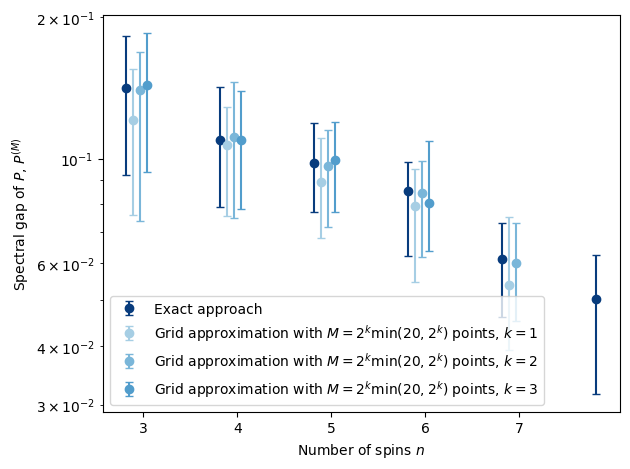

In [37]:
plot_spectral_gaps(spectral_gaps, is_transition=True)

## Validation of the construction of the coherent superposition of grid values

## Determine a single, fixed value of $(t^*, \gamma^*)$

There is no guarantee that there exists a single choice of $(t^*,\gamma^*)$ such that the corresponding proposal matrix $T(t^*,\gamma^*)$ is equal to the averaged proposal matrix. This is because the averaging is performed over the full matrix $T(t,\gamma)$, and the value of $(t,\gamma)$ reproducing the average of one matrix element is not necessarily the same as the value reproducing the average of another element. 

However, given the possibility of performing a grid search over the same ranges of $t$ and $\gamma$, one can identify the fixed pair $(t^*,\gamma^*)$ that yields the largest spectral gap, as shown in **TODO**. This does not reproduce the averaged proposal by construction, but provides the best fixed-parameter proposal within the explored parameter region.

Using a single fixed pair slighlty simplifies the quantum circuit. In particular, the additional register used to coherently encode the different values of $(t,\gamma)$ is no longer required, and the proposal unitary reduces to a single fixed $U(t^*,\gamma^*)$. The resulting walk therefore retains the original circuit structure without the additional parameter register and controlled selection over different proposal unitaries.